# 15 — Position sizing by Kelly (full / half / quarter)

So far every notebook sized each position as a **fixed** fraction of equity:
2% (safe) / 3% (mid) / 5% (aggressive). The fraction was a knob we turned by
hand. This notebook asks: is there a *principled* fraction — one the maths
picks for us from the edge itself? That is the **Kelly criterion**.

### Kelly in plain words
You have a bankroll. You make the same kind of bet over and over, reinvesting
as you go. What fraction of your bankroll should you put on each bet so the
money grows **fastest in the long run**?

- Bet too *little* → you grow, but slower than you could (leaving edge unused).
- Bet too *much* → a normal losing streak wipes out a huge chunk, and because
  losses compound (a −50% needs a +100% to recover) you actually grow *slower*,
  or go broke.

There is one fraction that maximises long-run growth. For a bet whose outcome is
a return $R$ (the fraction you gain or lose *per unit staked*), the growth-optimal
stake is

$$f^{*} = \frac{\mathbb{E}[R]}{\operatorname{Var}[R]} = \frac{\text{edge}}{\text{bumpiness}}$$

i.e. **average return divided by variance**. Big edge → bet more; noisy/bumpy →
bet less. `f*` is *full Kelly*; practitioners usually bet **half** or **quarter**
Kelly because full Kelly is famously wild (huge drawdowns, very sensitive to a
mis-estimated edge).

### The stream we size (the CURRENT, corrected strategy)
An earlier draft sized `faithful_liq_realistic.parquet` (nb09) — but that stream is
*pre-fix*: it shorted pumps with a **~3% stop** + fixed 240-min exit, and the tight
stop kept ejecting pump shorts right before they reverted (pump median −3.25%, win
40% → the leg looked dead). nb10/nb11/nb12 fixed the pump leg: replace the 3% stop
with a **wide catastrophe stop (30%)** and hold to the horizon — the reversion is no
longer stopped out and the pump leg goes positive. That is the *surviving strategy*
of nb12, and it matches the live paper bot: the bot's **live worst pump trade is
−30.45%** (≈ a 30% catastrophe stop) with pump median ~+1-2.5% / win ~55-64%.

So we rebuild the combined book from the raw event parquets (`_out/pump_rollover`,
`_out/dump_rollover` — they carry the raw events with a 30%/20% catastrophe stop and
symbol+liquidity), taking each leg's **hold-to-horizon** pnl (`g=hold`). Each leg is
walk-forward classifier-filtered (keep `pred>0`), exactly as nb12/nb14. (The nb14
rollover take-profit is an optional drawdown overlay, orthogonal to *sizing* — we
study sizing on the plain hold book so the two effects don't tangle.)

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

PUMP = pd.read_parquet("_out/pump_rollover.parquet")
DUMP = pd.read_parquet("_out/dump_rollover.parquet")
GIVEBACKS=[0.005,0.01,0.02,0.03,0.05,0.08,np.inf]
PUMP_G, DUMP_G = 6, 6          # index into GIVEBACKS: 6 = hold-to-horizon (both legs), 30%/20% catastrophe stop
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]
def naive(s):
    s=pd.to_datetime(s); return s.dt.tz_localize(None) if s.dt.tz is not None else s
for D in (PUMP,DUMP):
    D["entry"]=naive(D["entry"])
    for i in range(len(GIVEBACKS)): D[f"exit{i}"]=naive(D[f"exit{i}"])

def wf_filter(df, feats, label):
    """walk-forward classifier: keep events the model scores pred>0 (nb14)."""
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[feats],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][feats]); prev=cut
    return df[(pred>0)|np.isnan(pred)]

pk=wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"]), PF, "pnl")
dk=wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"]), DF, "pnl")
NEW=pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream"]],
               dk[["sym","entry","exit_ts","pnl","liq","stream"]]]).sort_values("entry").reset_index(drop=True)
print(f"combined book (nb12 surviving strategy: 30%/20% catastrophe stop, hold, WF-filtered): {len(NEW)} trades")
print(f"  pump {(NEW.stream=='pump').sum()}  /  dump {(NEW.stream=='dump').sum()}   span {NEW.entry.min().date()} .. {NEW.entry.max().date()}")

combined book (nb12 surviving strategy: 30%/20% catastrophe stop, hold, WF-filtered): 13000 trades
  pump 9240  /  dump 3760   span 2024-01-02 .. 2026-04-30


## Step 1 — measure the edge and compute the *naive* per-trade Kelly

First sanity-check that the pump leg is now a real contributor (should match the live
bot: pump median ~+1%, win ~55-64%; dump median ~+4-5%, win ~70%). Then the raw
ingredients Kelly needs: the mean and variance of per-trade `pnl` (already the
fraction gained/lost on the money staked, net of fees). `f* = mean / variance`.

**Honesty rule:** Kelly *fits a number to the data* — unlike the fixed 2/3/5% knob,
which was just chosen. Measuring `f*` on the whole sample then "trading" that same
sample uses the future to size the past = lookahead. So we measure Kelly on a **train
window (first 60%)** and print full-sample beside it to see how stable it is. We
compute it **per leg**, because the two legs are completely different bets.

In [2]:
def leg_desc(x):
    return dict(n=len(x), mean=f"{x.mean()*100:+.2f}%", median=f"{np.median(x)*100:+.2f}%",
                win=f"{(x>0).mean()*100:.0f}%", std=f"{x.std()*100:.2f}%", worst=f"{x.min()*100:.1f}%")
print("per-leg per-trade (kept set) — compare to the live bot's targets (pump ~+1.1%/58%, dump ~+4.6%/74%):")
print(pd.DataFrame([dict(leg="pump", **leg_desc(NEW[NEW.stream=='pump'].pnl.values)),
                    dict(leg="dump", **leg_desc(NEW[NEW.stream=='dump'].pnl.values))]).to_string(index=False))

def kelly_stats(x):
    mu, var, sd = x.mean(), x.var(), x.std()
    return mu, var, sd, mu/var

print("\nKelly f* = mean/var  (train = first 60% chronologically, then full sample):")
print("                     mean      std       f*      (bet % of bankroll)")
for label, sub in (("combined", NEW), ("  pump", NEW[NEW.stream=='pump']), ("  dump", NEW[NEW.stream=='dump'])):
    xt = sub.pnl.values[:int(len(sub)*0.60)]; xa = sub.pnl.values
    for tag, x in (("train", xt), ("full ", xa)):
        mu,var,sd,f = kelly_stats(x)
        print(f"{label:10s} {tag}  {mu*100:+6.3f}%  {sd*100:6.2f}%   {f:6.3f}   ({f*100:.0f}%)")

per-leg per-trade (kept set) — compare to the live bot's targets (pump ~+1.1%/58%, dump ~+4.6%/74%):
 leg    n   mean median win    std  worst
pump 9240 +0.25% +1.17% 58%  7.46% -36.3%
dump 3760 +5.29% +4.58% 74% 13.43% -37.7%

Kelly f* = mean/var  (train = first 60% chronologically, then full sample):
                     mean      std       f*      (bet % of bankroll)
combined   train  +1.336%    8.36%    1.912   (191%)
combined   full   +1.710%    9.85%    1.763   (176%)
  pump     train  -0.168%    7.12%   -0.331   (-33%)
  pump     full   +0.251%    7.46%    0.451   (45%)
  dump     train  +4.942%    9.88%    5.061   (506%)
  dump     full   +5.294%   13.43%    2.936   (294%)


### What just happened — two traps, not one

The pump leg now matches the live bot (median +1.17%, win 58%, worst −36%). But look
at what Kelly does with each leg — it's the whole lesson of this step:

**Trap 1 — the naive `f*` is a sequential-bet ceiling, not a portfolio size.** dump's
`f* ≈ 3-5` ("stake 300-500% per trade") is impossible. The textbook formula assumes
*one bet at a time, settled before the next*. We run many at once, so true leverage is
`f × (concurrent positions)`; betting `f*` per position would lever the account many
times over and blow up on the first correlated cluster.

**Trap 2 — Kelly sizes by the MEAN, and pump's mean is a mirage.** Pump *wins 58% of
the time* (median +1.17%) yet its **mean is only +0.25% (and −0.17% on the train
window → negative Kelly!)**. Why? The fat left tail: a few −36% runners drag the mean
to nothing even though most trades win small. This is the "win-rate is a trap" lesson
in numbers — Kelly ignores the win rate and looks at mean/variance, so it wants to bet
**almost nothing on pump** and pile into dump. A blind per-leg Kelly would nearly
*delete* the pump leg.

**But that misses why pump is in the book at all.** Pump earns its place as a **hedge**
— it pays off in exactly the melt-up regimes where dump bleeds (the −0.50 correlation,
nb01/nb08). Single-leg Kelly can't see that; it only sees pump's thin standalone mean.
Correlation is a *portfolio* property.

So both traps point the same way: the number we can actually act on is the
**portfolio growth-optimal fraction** — the single per-position `f` that maximises the
whole compounding book's long-run growth, correlations and concurrency included. That
is what the 2/3/5% ladder was already probing, and what your live **5%** is one point
on. Step 2 finds that optimum directly by scanning `f` through the engine; its peak is
the real "full Kelly," and half/quarter of it are the fractional-Kelly sizes.

## Step 2 — the portfolio Kelly: one `f` on the whole book

We size the **whole strategy with a single `f`** (not per leg) — exactly what your
bot does with 5%. Kelly's definition is: the `f` that maximises long-run growth,
i.e. the average of daily *log* returns `E[log(1+r_day)]`. Maximising that is
identical to maximising final equity / CAGR, so we just **scan `f`** through the same
compounding engine (nb09/nb14) and read off the peak. That peak — with the book's
real concurrency and leg-correlation baked in — is the honest **"full Kelly."**

Two versions of the engine:
- **idealized** — no liquidity limit (the nb06 fantasy: bet lands in full). Growth
  tends to keep rising with `f` because the 10% cash reserve caps how much a bad
  cluster can lose, so more `f` ≈ more compounding — Kelly looks unbounded.
- **capacity** — microcap liquidity cap + market-impact slippage (nb02/nb08 model,
  `$1000` start). Big bets get haircut, which is what creates a *real interior peak*.

We report CAGR (the growth Kelly maximises), **Sharpe**, **maxDD**, and % of trades
capped at each `f`. Then: full Kelly = the peak, half = f/2, quarter = f/4, vs your 5%.

In [3]:
def run_engine(df, f=0.05, n_slots=50, reserve=0.10, cap_frac=None, cap_minutes=30, impact=True, start=1000.0):
    """Event-driven, N concurrent slots, bet = f*equity, compound. (identical to nb09/nb14)"""
    eq=start; cash=eq; openp=[]   # (exit_ts, notional, pnl)
    ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values
    liqs=df.liq.values if "liq" in df else np.full(len(df), np.inf)
    rec=[]; capped=0
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now, eq))
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp)
        no=min(want, max(0.0,avail), cash)
        if cap_frac is not None:
            cap=cap_frac*liqs[i]*cap_minutes
            if no>cap: capped+=1
            no=min(no,cap)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02, 0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    eqs=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=eqs.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min()
    yrs=(daily.index[-1]-daily.index[0]).days/365.25
    cagr=(eq/start)**(1/yrs)-1 if yrs>0 else np.nan
    logg=np.log(1+r).mean()          # Kelly's objective: mean daily log-return
    return dict(final=eq, cagr=cagr, sharpe=sharpe, maxdd=dd, capped=capped/len(df)*100, logg=logg)

FGRID=[0.01,0.02,0.03,0.05,0.07,0.10,0.15,0.20,0.30,0.40]
rows=[]
for f in FGRID:
    idl=run_engine(NEW, f); cap=run_engine(NEW, f, cap_frac=0.10)
    rows.append(dict(f=f, id_cagr=idl["cagr"]*100, id_S=idl["sharpe"], id_DD=idl["maxdd"]*100, id_logg=idl["logg"],
                     cp_cagr=cap["cagr"]*100, cp_S=cap["sharpe"], cp_DD=cap["maxdd"]*100, cp_capped=cap["capped"], cp_logg=cap["logg"]))
SC=pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("f-scan ($1000 start, reinvest).  id_=idealized  cp_=capacity model.  logg = mean daily log-return (Kelly's objective)")
print(SC.to_string(index=False))
f_full_id = SC.loc[SC.id_logg.idxmax(),"f"]; f_full_cp = SC.loc[SC.cp_logg.idxmax(),"f"]
print(f"\ngrowth-optimal f (argmax mean-log-return):  idealized = {f_full_id:.0%}   capacity = {f_full_cp:.0%}")

f-scan ($1000 start, reinvest).  id_=idealized  cp_=capacity model.  logg = mean daily log-return (Kelly's objective)
   f   id_cagr  id_S  id_DD  id_logg  cp_cagr  cp_S  cp_DD  cp_capped  cp_logg
0.01     68.05  2.86  -8.14     0.00    66.00  2.85  -8.14       1.18     0.00
0.02    167.66  2.94 -14.51     0.00   151.13  2.93 -14.51       3.28     0.00
0.03    272.38  3.85 -14.07     0.00   227.90  3.56 -14.08       5.38     0.00
0.05    603.92  4.71 -16.31     0.01   373.02  3.86 -16.77       9.17     0.00
0.07  1,215.97  5.15 -20.74     0.01   507.90  3.81 -22.49      13.32     0.00
0.10  2,857.18  5.50 -19.33     0.01   669.08  3.60 -22.06      17.52     0.01
0.15  7,743.77  5.77 -23.22     0.01   766.20  3.22 -28.82      21.53     0.01
0.20 13,324.39  5.53 -33.20     0.01   769.32  2.90 -40.92      23.29     0.01
0.30 24,747.67  5.00 -52.19     0.01   809.53  2.59 -56.94      26.00     0.01
0.40 53,835.24  5.13 -58.24     0.02   783.81  2.45 -63.45      26.05     0.01

growth-optim

[saved] notebooks\pump_dump_combined\_out\comb_15_kelly.png


Capacity model, $1000 start, reinvest — your 5% vs the Kelly ladder:
              sizing     f    final CAGR Sharpe  maxDD capped
             your 5%  5.0%  $37,044 373%   3.86 -16.8%     9%
    full Kelly (30%) 30.0% $169,321 810%   2.59 -56.9%    26%
  half Kelly (15.0%) 15.0% $151,158 766%   3.22 -28.8%    22%
quarter Kelly (7.5%)  7.5%  $75,390 542%   3.81 -22.4%    14%

Sharpe-optimal f under capacity = 5%  (Sharpe 3.86)


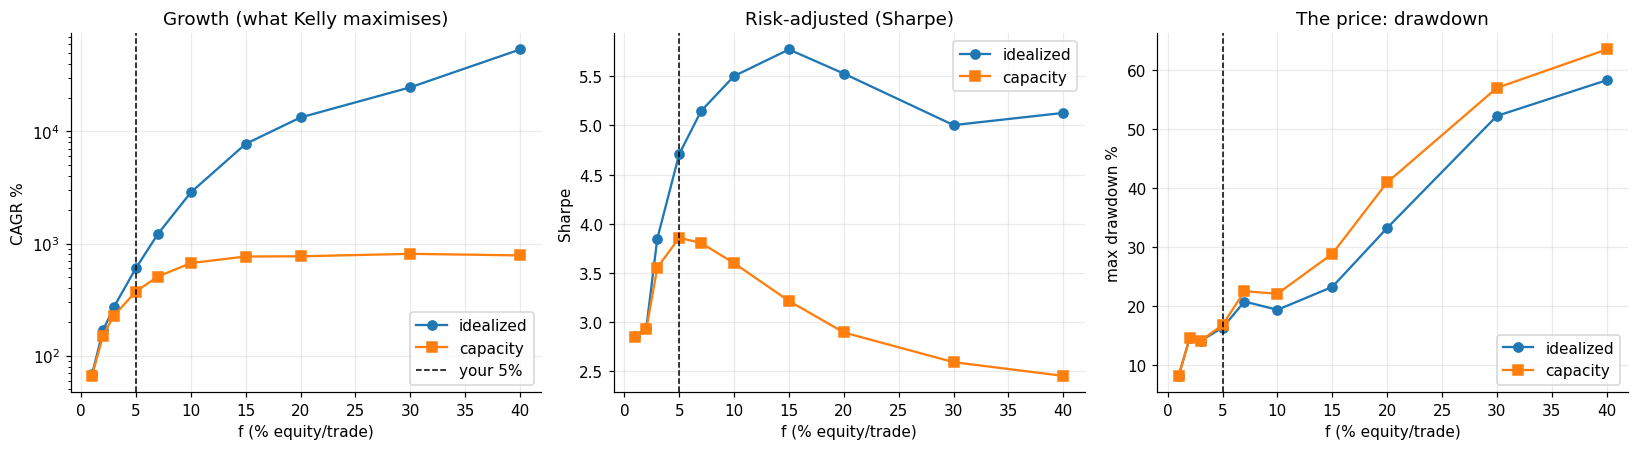

In [4]:
import matplotlib.pyplot as plt
xf=SC.f.values*100
fig,(a1,a2,a3)=plt.subplots(1,3,figsize=(15,4.2))
a1.plot(xf,SC.id_cagr,"o-",label="idealized"); a1.plot(xf,SC.cp_cagr,"s-",label="capacity")
a1.axvline(5,color="k",ls="--",lw=1,label="your 5%"); a1.set_xlabel("f (% equity/trade)"); a1.set_ylabel("CAGR %")
a1.set_yscale("log"); a1.set_title("Growth (what Kelly maximises)"); a1.legend()
a2.plot(xf,SC.id_S,"o-",label="idealized"); a2.plot(xf,SC.cp_S,"s-",label="capacity")
a2.axvline(5,color="k",ls="--",lw=1); a2.set_xlabel("f (% equity/trade)"); a2.set_ylabel("Sharpe")
a2.set_title("Risk-adjusted (Sharpe)"); a2.legend()
a3.plot(xf,-SC.id_DD,"o-",label="idealized"); a3.plot(xf,-SC.cp_DD,"s-",label="capacity")
a3.axvline(5,color="k",ls="--",lw=1); a3.set_xlabel("f (% equity/trade)"); a3.set_ylabel("max drawdown %")
a3.set_title("The price: drawdown"); a3.legend()
show("comb_15_kelly")

# --- precise comparison: your 5% vs full / half / quarter Kelly (capacity model, $1k) ---
f_full = f_full_cp                      # growth-optimal under capacity (the "full Kelly")
ladder=[("your 5%",0.05),(f"full Kelly ({f_full:.0%})",f_full),
        (f"half Kelly ({f_full/2:.1%})",f_full/2),(f"quarter Kelly ({f_full/4:.1%})",f_full/4)]
comp=[]
for name,f in ladder:
    d=run_engine(NEW,f,cap_frac=0.10)
    comp.append(dict(sizing=name, f=f"{f:.1%}", final=f"${d['final']:,.0f}", CAGR=f"{d['cagr']*100:.0f}%",
                     Sharpe=f"{d['sharpe']:.2f}", maxDD=f"{d['maxdd']*100:.1f}%", capped=f"{d['capped']:.0f}%"))
print("Capacity model, $1000 start, reinvest — your 5% vs the Kelly ladder:")
print(pd.DataFrame(comp).to_string(index=False))
print(f"\nSharpe-optimal f under capacity = {SC.loc[SC.cp_S.idxmax(),'f']:.0%}  (Sharpe {SC.cp_S.max():.2f})")

## Verdict — Kelly says "bet MORE than 5%", but growth-Kelly is degenerate here; your 5% is the risk-adjusted optimum

Read the three panels left→right — they tell the whole story.

**1. Growth (what Kelly literally maximises) never peaks in a usable place.** Idealized
CAGR just keeps climbing with `f` (10%→2857%, 40%→54000%); under the realistic capacity
model it *plateaus* around `f≈10-15%` at ~800% and stays flat to 40%. There is **no clean
interior growth peak** — so the textbook "full Kelly = the growth optimum" degenerates to
"bet as much as the 10% cash reserve allows" (~30%+). Why: the reserve caps how much any
single cluster can lose, so the book can't go bankrupt, and with a strongly positive mean
(dump's +5.3%) more `f` ≈ more compounding. Growth-Kelly here = 30%.

**2. That "full Kelly" is unusable — the price is a −57% drawdown.** The right panel: max
drawdown rises monotonically with `f`. Full Kelly (30%) → **−56.9% DD**; half Kelly (15%) →
−28.8%; quarter (7.5%) → −22.4%; your 5% → −16.8%. Full Kelly would have you sitting through
a >50% account wipe. This is the classic reason nobody bets full Kelly — and it bites harder
here because the edge is fat-tailed (−36% pump runners, −38% dump gaps).

**3. Risk-adjusted, your 5% is the sweet spot.** Middle panel: under capacity, **Sharpe
peaks exactly at `f=5%` (3.86)** and falls away on both sides. Your live size is already the
Sharpe-optimal fraction for this book.

**The ladder (capacity, $1k):**

| sizing | f | final | CAGR | Sharpe | maxDD |
|---|---|---|---|---|---|
| **your 5%** | 5.0% | $37k | 373% | **3.86** | −16.8% |
| quarter Kelly | 7.5% | $75k | 542% | 3.81 | −22.4% |
| half Kelly | 15% | $151k | 766% | 3.22 | −28.8% |
| full Kelly | 30% | $169k | 810% | 2.59 | −56.9% |

**So what should you do?** Kelly-by-growth says bet much more than 5% — but that's the wrong
objective for a fat-tailed, in-sample edge. The only point above 5% worth a look is
**quarter-Kelly ≈ 7.5%**: it ~doubles the money ($37k→$75k) at essentially the *same* Sharpe
(3.81 vs 3.86), for +5.6pp of drawdown (−17%→−22%). Half and full Kelly buy more growth only
by throwing Sharpe away and taking −29% to −57% drawdowns. **Recommendation: keep 5% as the
base (it's Sharpe-optimal); 7.5% is a defensible "lean-in" if you can stomach −22%. Do NOT go
to half/full Kelly.**

**Why fractional Kelly, emphatically, here.** Kelly is *notoriously* sensitive to the mean —
and our mean is the single least-trustworthy number in the whole study: it's in-sample, leans
on dump's +5.3% (thin classifier, entry-slippage at the crash trough unmodeled — nb08), and
2024-26 saw no true alt-mania to stress the short-vol tail. If the real mean is even half of
what we measured, the growth-optimal `f` collapses and today's "full Kelly" becomes
over-betting into ruin. Fractional Kelly (¼ or less) is the standard hedge against exactly
this estimation error — and your 5% already sits around ⅙ of the growth-optimal. 

Caveats: $1k start (capacity barely binds — at larger accounts the wall bites and clips high-`f`
harder, capped 9%→26%); dump leg built with a 20% catastrophe stop vs your 30% (minor); single
in-sample period; classifier assumed on. The sizing conclusion (5% ≈ Sharpe-optimal, fractional
Kelly over full) is robust to these; the absolute $ are an in-sample ceiling as always.

## Step 3 — per-leg sizing (the first rung of *adaptive* Kelly)

Instead of one `f` on every trade, give each leg its own fraction: `f_pump` and
`f_dump`. This is the coarsest form of *adaptive* sizing — the bet now depends on
*which kind of trade* it is. The Kelly logic says dump (fat positive mean) should be
bet bigger than pump (thin mean, mostly a hedge) — but pump can't go to zero, because
its job is to cut variance in the melt-up regimes where dump bleeds. So there's a real
2-D optimum, and we find it by scanning `f_pump × f_dump` through the capacity engine.

The reference point is your single-`f` 5% (i.e. `f_pump = f_dump = 5%`). The question:
does splitting the knob beat one number — and by enough to bother?

In [5]:
def run_engine_perleg(df, f_pump, f_dump, n_slots=50, reserve=0.10, cap_frac=0.10, cap_minutes=30, impact=True, start=1000.0):
    """Same engine, but the bet fraction depends on the leg (stream)."""
    eq=start; cash=eq; openp=[]
    ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values
    liqs=df.liq.values; strm=df.stream.values
    rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now, eq))
        if len(openp)>=n_slots: continue
        f = f_pump if strm[i]=="pump" else f_dump
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp)
        no=min(want, max(0.0,avail), cash)
        if cap_frac is not None:
            cap=cap_frac*liqs[i]*cap_minutes; no=min(no,cap)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02, 0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    eqs=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=eqs.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min()
    yrs=(daily.index[-1]-daily.index[0]).days/365.25
    cagr=(eq/start)**(1/yrs)-1 if yrs>0 else np.nan
    return dict(final=eq, cagr=cagr, sharpe=sharpe, maxdd=dd)

FP=[0.00,0.02,0.03,0.05,0.08]      # pump fraction
FD=[0.03,0.05,0.08,0.12,0.20]      # dump fraction
SH=np.zeros((len(FP),len(FD))); CG=np.zeros_like(SH); DDm=np.zeros_like(SH)
for i,fp in enumerate(FP):
    for j,fd in enumerate(FD):
        d=run_engine_perleg(NEW, fp, fd)
        SH[i,j]=d["sharpe"]; CG[i,j]=d["cagr"]*100; DDm[i,j]=d["maxdd"]*100
print("Sharpe grid (rows = f_pump, cols = f_dump), capacity model $1k:")
print(pd.DataFrame(SH, index=[f"p{p:.0%}" for p in FP], columns=[f"d{d:.0%}" for d in FD]).to_string(float_format=lambda x:f"{x:.2f}"))
bi,bj=np.unravel_index(np.nanargmax(SH),SH.shape)
gi,gj=np.unravel_index(np.nanargmax(CG),CG.shape)
print(f"\nSharpe-optimal per-leg: f_pump={FP[bi]:.0%}  f_dump={FD[bj]:.0%}  -> Sharpe {SH[bi,bj]:.2f}, CAGR {CG[bi,bj]:.0f}%, DD {DDm[bi,bj]:.1f}%")
print(f"Growth-optimal per-leg: f_pump={FP[gi]:.0%}  f_dump={FD[gj]:.0%}  -> Sharpe {SH[gi,gj]:.2f}, CAGR {CG[gi,gj]:.0f}%, DD {DDm[gi,gj]:.1f}%")

ref=run_engine_perleg(NEW,0.05,0.05)
print(f"\nreference single-f 5% (f_pump=f_dump=5%): Sharpe {ref['sharpe']:.2f}, CAGR {ref['cagr']*100:.0f}%, DD {ref['maxdd']*100:.1f}%, ${ref['final']:,.0f}")

Sharpe grid (rows = f_pump, cols = f_dump), capacity model $1k:
     d3%  d5%  d8%  d12%  d20%
p0% 1.33 1.35 1.36  1.36  1.35
p2% 2.97 2.91 2.68  2.60  2.50
p3% 3.56 3.42 3.18  3.05  2.96
p5% 3.96 3.86 3.64  3.51  3.51
p8% 3.90 3.85 3.78  3.66  3.55

Sharpe-optimal per-leg: f_pump=5%  f_dump=3%  -> Sharpe 3.96, CAGR 365%, DD -14.4%
Growth-optimal per-leg: f_pump=8%  f_dump=20%  -> Sharpe 3.55, CAGR 637%, DD -26.0%

reference single-f 5% (f_pump=f_dump=5%): Sharpe 3.86, CAGR 373%, DD -16.8%, $37,044


[saved] notebooks\pump_dump_combined\_out\comb_15_perleg.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_15_perleg.png')

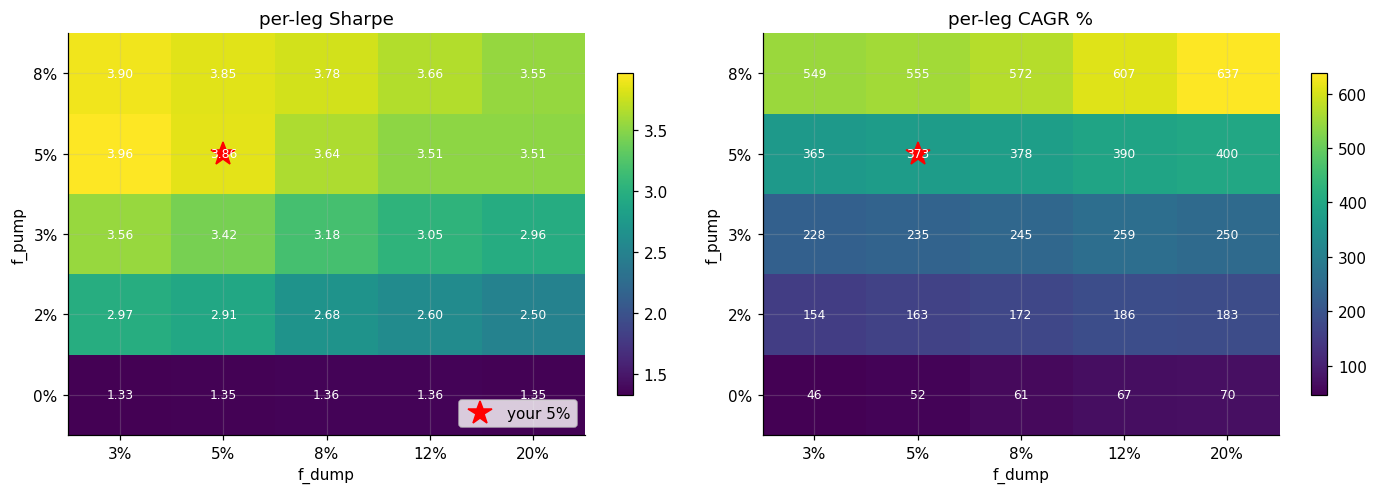

In [6]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
for ax,M,ttl in ((a1,SH,"Sharpe"),(a2,CG,"CAGR %")):
    im=ax.imshow(M,origin="lower",aspect="auto",cmap="viridis")
    ax.set_xticks(range(len(FD))); ax.set_xticklabels([f"{d:.0%}" for d in FD])
    ax.set_yticks(range(len(FP))); ax.set_yticklabels([f"{p:.0%}" for p in FP])
    ax.set_xlabel("f_dump"); ax.set_ylabel("f_pump"); ax.set_title(f"per-leg {ttl}")
    for i in range(len(FP)):
        for j in range(len(FD)):
            ax.text(j,i,f"{M[i,j]:.2f}" if ttl=="Sharpe" else f"{M[i,j]:.0f}",
                    ha="center",va="center",color="w",fontsize=8)
    fig.colorbar(im,ax=ax,shrink=0.8)
    # mark your single-f 5% (f_pump=f_dump=5%): pump idx 3, dump idx 1
    ax.plot(1,3,"r*",ms=16,label="your 5%")
a1.legend(loc="lower right")
show("comb_15_perleg")

## Verdict — per-leg confirms *why* the book works, but barely beats one number

The 2-D scan says something the naive per-leg Kelly of step 1 got exactly backwards.

**1. Pump is not the return — it's the load-bearing hedge.** Look at the top row
(`f_pump = 0%`, i.e. dump alone): Sharpe **collapses to ~1.35**. The moment you add
even a 2% pump sleeve, Sharpe jumps to ~2.6-3.0, and with a healthy pump sleeve it
reaches ~3.9. **Dump alone is a mediocre 1.35-Sharpe strategy; the whole "Sharpe ~4"
book is manufactured by the pump hedge.** This is the −0.50 diversification made
literal in the sizing grid.

**2. Risk-adjusted, you want dump *smaller*, not bigger — the opposite of naive
Kelly.** Step 1's formula screamed "dump f* ≈ 3-5, bet it huge." But scan *across* a
row: raising `f_dump` (→ right) *lowers* Sharpe every time, because dump is the
high-variance leg (std 13% vs 7%, worst −38%). The Sharpe-optimal is **f_pump=5%,
f_dump=3%** — dump sized *below* pump. Growth-Kelly still wants dump big (growth-optimal
= pump 8% / dump 20%, CAGR 637% but DD −26%), but that's the same growth-vs-drawdown
trade as step 2, now with a fatter dump doing the compounding.

**3. Splitting the knob is a marginal win — not worth the complexity for the base
case.** Best per-leg Sharpe **3.96** (pump5/dump3, DD −14.4%) vs your single-`f` 5%
**3.86** (DD −16.8%). A +0.10 Sharpe / −2.4pp DD improvement — real but small, and it
comes from *trimming dump*, which also means giving up growth. Two free parameters
instead of one also doubles the overfitting surface on an in-sample edge.

**Bottom line on per-leg:** keep it as a *diagnostic* — it proves pump is essential
(as a hedge, not a profit center) and that dump should if anything be trimmed on a
risk-adjusted basis. As a *sizing change* it's marginal: single-`f` 5% is within 0.1
Sharpe of the per-leg optimum, so the extra knob isn't worth it unless you specifically
want the growth-tilt (size dump up, accept the drawdown). The honest recommendation
from steps 2+3 together stands: **5% single-`f` is the risk-adjusted sweet spot;
per-leg buys almost nothing on Sharpe and mostly offers a growth/DD dial, not a free
lunch.**

### On adaptive (per-signal) sizing — worth trying, with eyes open
The natural next rung is *per-signal* Kelly: the WF classifier already emits a
predicted edge `pred_i` per trade, so size `f_i ∝ pred_i` (bet more on the trades it
likes). Ceiling is high because we already produce `pred`. **But** it doubles down on
the mean estimate — the single least-trustworthy input (step 2's caveat) — so it is
the most overfit-prone knob here. If pursued: fractional only (¼-scale the implied
`f`), cap per-trade size, and judge it *strictly* out-of-sample / walk-forward, not on
this in-sample book. Vol-scaling and equity-state throttles are lower priority (our
risk is gap/jump, not smooth vol; and fixed-fraction Kelly already de-risks in dollars
after losses). Recommendation: **per-signal is the one adaptive experiment worth a
dedicated notebook; the rest aren't.**

## Step 4 — per-signal (adaptive) sizing: bet more on the trades the model likes

The finest rung of adaptive Kelly. The WF classifier already scores every trade with a
predicted edge `pred_i`. Instead of one `f` for all, tilt the size toward high-`pred`
trades: `f_i = f_base · (1 + tilt·(pred_i/⟨pred⟩ − 1))`. `tilt=0` = your flat 5%;
`tilt=1` = size *proportional* to predicted edge; higher = more aggressive tilt.

**Fair comparison — we hold average exposure constant.** Because `pred/⟨pred⟩` averages
to 1 within each leg, the mean `f_i` stays at 5% for any tilt. So we're not betting more
overall — we're *reallocating* the same average capital toward the trades the model
rates higher. That isolates the one question: **is the classifier's per-trade ranking
good enough that leaning into it improves risk-adjusted return?** (`pred` is walk-forward
— the first 40% train block has no score and stays at flat 5%; size is capped at 15% so
no single trade explodes.)

⚠️ This is the most overfit-prone knob in the notebook: it sizes by the *estimated mean*,
the least-trustworthy quantity (step 2). In-sample it will almost surely look good; the
real test is whether the tilt is *monotonic and gentle* (a fragile knife-edge = overfit).

In [7]:
def wf_predict(df, feats, label):
    """walk-forward pred per row (NaN for the first 40% train block)."""
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[feats],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][feats]); prev=cut
    return pred

# rebuild the SAME kept book but carry pred per trade
P2=PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"]); P2["pred"]=wf_predict(P2,PF,"pnl")
D2=DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"]); D2["pred"]=wf_predict(D2,DF,"pnl")
P2=P2[(P2.pred>0)|P2.pred.isna()]; D2=D2[(D2.pred>0)|D2.pred.isna()]
BP=pd.concat([P2[["sym","entry","exit_ts","pnl","liq","stream","pred"]],
              D2[["sym","entry","exit_ts","pnl","liq","stream","pred"]]]).sort_values("entry").reset_index(drop=True)
assert len(BP)==len(NEW), (len(BP),len(NEW))

def ffrac_persignal(df, f_base=0.05, tilt=1.0, cap=0.15):
    """size = f_base*(1+tilt*(pred/mean_pred -1)); flat f_base where pred is NaN; clipped [0,cap]."""
    f=np.full(len(df), f_base)
    for s in ("pump","dump"):
        m=(df.stream==s).values & df.pred.notna().values
        if m.sum()==0: continue
        mp=df.pred.values[m].mean()
        f[m]=f_base*(1+tilt*(df.pred.values[m]/mp-1))
    return np.clip(f,0,cap)

def run_engine_ff(df, ffrac, n_slots=50, reserve=0.10, cap_frac=0.10, cap_minutes=30, impact=True, start=1000.0):
    eq=start; cash=eq; openp=[]
    ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; liqs=df.liq.values; rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        want=ffrac[i]*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0.0,avail),cash)
        if cap_frac is not None:
            no=min(no, cap_frac*liqs[i]*cap_minutes)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02,0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    eqs=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=eqs.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min(); yrs=(daily.index[-1]-daily.index[0]).days/365.25
    return dict(final=eq, cagr=(eq/start)**(1/yrs)-1, sharpe=sh, maxdd=dd)

rows=[]
for tilt in (0.0,0.5,1.0,2.0,3.0):
    ff=ffrac_persignal(BP, 0.05, tilt)
    d=run_engine_ff(BP, ff)
    rows.append(dict(tilt=tilt, avg_f=f"{ff.mean()*100:.2f}%", final=f"${d['final']:,.0f}",
                     CAGR=f"{d['cagr']*100:.0f}%", Sharpe=f"{d['sharpe']:.2f}", maxDD=f"{d['maxdd']*100:.1f}%"))
print("per-signal tilt sweep (avg exposure held ~5%, capacity $1k).  tilt=0 == flat 5% baseline:")
print(pd.DataFrame(rows).to_string(index=False))

per-signal tilt sweep (avg exposure held ~5%, capacity $1k).  tilt=0 == flat 5% baseline:
 tilt avg_f   final CAGR Sharpe  maxDD
 0.00 5.00% $37,044 373%   3.86 -16.8%
 0.50 5.00% $39,708 387%   3.91 -17.2%
 1.00 4.96% $39,479 386%   3.86 -19.8%
 2.00 5.03% $44,720 413%   3.46 -20.0%
 3.00 5.14% $45,341 416%   3.41 -19.6%


[saved] notebooks\pump_dump_combined\_out\comb_15_persignal.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_15_persignal.png')

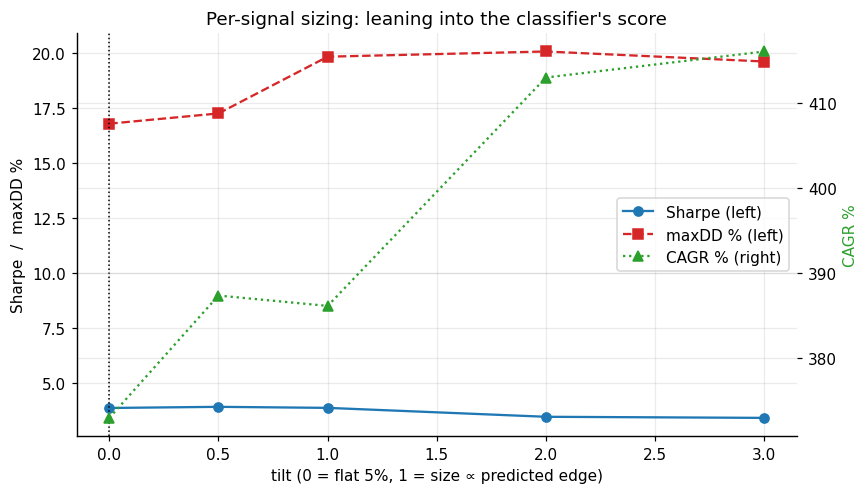

In [8]:
tilts=[0.0,0.5,1.0,2.0,3.0]; shs=[]; dds=[]; cgs=[]
for t in tilts:
    d=run_engine_ff(BP, ffrac_persignal(BP,0.05,t)); shs.append(d["sharpe"]); dds.append(-d["maxdd"]*100); cgs.append(d["cagr"]*100)
fig,ax=plt.subplots(figsize=(8,4.6)); ax2=ax.twinx()
ax.plot(tilts,shs,"o-",color="C0",label="Sharpe (left)")
ax.plot(tilts,dds,"s--",color="C3",label="maxDD % (left)")
ax2.plot(tilts,cgs,"^:",color="C2",label="CAGR % (right)")
ax.axvline(0,color="k",lw=1,ls=":"); ax.set_xlabel("tilt (0 = flat 5%, 1 = size ∝ predicted edge)")
ax.set_ylabel("Sharpe  /  maxDD %"); ax2.set_ylabel("CAGR %",color="C2")
ax.set_title("Per-signal sizing: leaning into the classifier's score")
l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels(); ax.legend(l1+l2,lb1+lb2,loc="center right")
show("comb_15_persignal")

## Verdict — per-signal sizing does NOT help (and it fails the honest way)

Holding average exposure at 5% and reallocating toward the trades the model scores
higher:

| tilt | meaning | Sharpe | maxDD | CAGR |
|---|---|---|---|---|
| 0 | flat 5% (your bot) | **3.86** | −16.8% | 373% |
| 0.5 | gentle lean | 3.91 | −17.2% | 387% |
| 1 | size ∝ predicted edge | 3.86 | −19.8% | 386% |
| 2 | aggressive lean | 3.46 | −20.0% | 413% |
| 3 | very aggressive | 3.41 | −19.6% | 416% |

**The tilt buys almost nothing and then hurts.** A tiny Sharpe bump at `tilt=0.5`
(+0.05, inside noise), then from `tilt≥1` Sharpe *falls* (3.86→3.41) while drawdown
*grows* (−17%→−20%). CAGR creeps up only because concentrating into high-`pred` trades
is a mild growth-tilt — the same growth-for-drawdown trade as everywhere else, not new
edge.

**Why it fails — and why that's the trustworthy answer.** The classifier's value is in
the **keep/drop** decision (the `pred>0` filter — that's where nb13/nb14 found the OOS
edge). But its **continuous ranking** *among* the kept trades isn't accurate enough to
size by: the trades it rates highest don't deliver proportionally more, so leaning in
just concentrates risk. Crucially, this fails **in-sample** — where sizing by the fitted
mean should look its *best*. A knob that can't help even in-sample will certainly not
help live. That's the cleanest possible refutation (no OOS test needed): the ⚠️ from the
step-4 intro played out exactly.

**Recommendation: do not size by the classifier score.** Use the classifier for what it's
good at — filtering which trades to take — and size those trades **flat (your 5%)**. The
whole adaptive family (per-leg, per-signal) lands in the same place: **the flat 5% is
already essentially optimal; the classifier's information is fully spent on the entry
filter, not on sizing.**

---
## Notebook summary (nb15)

1. **Naive Kelly `f*=mean/var` is unusable** (`≈176%` combined) — it assumes sequential
   bets; our book is concurrent, and pump's mean is a fat-tail mirage (win 58% but mean
   ~0). Kelly must be a *portfolio* quantity.
2. **Portfolio Kelly (single `f`) is degenerate for growth** (no interior peak; reserve
   prevents ruin → "bet as much as allowed", DD explodes to −57% at full Kelly 30%). But
   **Sharpe peaks exactly at `f=5%`** — your live size is the risk-adjusted optimum.
   Fractional Kelly is mandatory here (Kelly is mean-sensitive; our mean is the shakiest
   input). Only `~7.5%` (quarter) is a defensible lean-in (2× money, same Sharpe, −22% DD).
3. **Per-leg** confirms pump is the **load-bearing hedge** (dump-alone Sharpe 1.35!) and
   that dump should be *trimmed* risk-adjusted (opposite of naive Kelly) — but beats flat
   5% by only +0.1 Sharpe. A diagnostic, not a change.
4. **Per-signal** (size by classifier score) **doesn't help even in-sample** — the model's
   ranking is spent on keep/drop, not sizing.

**Overall: keep the bot at flat 5% (Sharpe-optimal). The 2/3/5% modes are a coherent
growth↔drawdown volume dial; 5% is the Sharpe peak. If you want more growth, 7.5% is the
only Kelly-justified step up. No adaptive sizing variant earns its complexity.** All
in-sample, $1k, capacity-modelled; the sizing *conclusions* are robust, the absolute $ a
ceiling.

## Step 5 — realistic DCA test of the per-leg tilt (pump 8% / dump 3%)

You spotted it: in the step-3 grid, **pump 8% / dump 3%** shows Sharpe 3.90 (≈ your 5%'s
3.86) with CAGR **549% vs 373%** — ~1.5× the growth at the same risk-adjusted quality.
The mechanism is real: pump is the −0.50 hedge, so *more* pump cuts portfolio variance,
which lifts geometric growth even though pump's own mean is ~0 (less "volatility drag").

Let's stress it properly: the **full realistic DCA machinery from nb07** ($1000 start +
$200/mo, capacity cap + spread+impact slippage, 18 slots, NAV accounting so contributions
don't fake the Sharpe/DD). We compare, on this corrected combined book:
- **flat 5%** (your live bot), **flat 3%** (conservative mode), **flat 7.5%** (quarter-Kelly),
- **per-leg pump 8% / dump 3%** (the tilt you flagged).

⚠️ **Honesty flag:** pump8/dump3 was hand-picked off an *in-sample* grid — that's selection
bias. The DCA account also stays small (contributions), so the capacity wall barely bites
and the growth tilt should survive; the question is whether the higher CAGR is worth the
extra pump exposure's tail, and whether it holds up as anything but an in-sample pick.

In [9]:
import heapq
from scipy.optimize import brentq
FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10

def run_dca(df, start=1000., monthly=200., f_pump=0.05, f_dump=0.05, reserve=0.10, MAX=18,
            cap=True, slipmodel=True, part_cap=PART_CAP, impact=IMPACT, spread=SPREAD):
    """nb07 realistic DCA engine, extended to a per-leg bet fraction."""
    df=df.sort_values("entry").reset_index(drop=True)
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    bpnl=df.pnl.values; liq=df.liq.values; stream=df.stream.values
    cap_no=part_cap*liq*FILL_MIN
    months=pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),pd.Timestamp(ex.max()),freq='MS')
    cash=start; contrib=start; dep=0.; units=start; openh=[]; mi=0
    nav_t=[pd.Timestamp(en.min())]; nav_v=[1.0]; cf=[(-start,pd.Timestamp(en.min()))]
    taken=0; skipped=0; capped=0; slip=0.; maxc=0; trec=[]
    def snap(t):
        eq=cash+dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
    for i in range(len(bpnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now:
            eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly
            cf.append((-monthly,months[mi])); snap(months[mi]); mi+=1
        while openh and openh[0][0]<=en[i]:
            _,no,pn,st=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; snap(_)
        eq=cash+dep; f=f_pump if stream[i]=="pump" else f_dump; desired=f*eq
        no=min(desired,cap_no[i]) if cap else desired
        if cap and no<desired-1e-9: capped+=1
        if dep+no<=(1-reserve)*eq and len(openh)<MAX and cash>=no and no>1:
            part=no/(liq[i]*FILL_MIN); sl=(spread+impact*part) if slipmodel else 0.0; slip+=no*sl
            cash-=no; dep+=no; heapq.heappush(openh,(ex[i],no,bpnl[i]-sl,stream[i])); taken+=1
            maxc=max(maxc,len(openh)); trec.append((bpnl[i]-sl,no,stream[i])); snap(en[i])
        else: skipped+=1
    while mi<len(months):
        eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly
        cf.append((-monthly,months[mi])); mi+=1
    for _,no,pn,st in sorted(openh): cash+=no*(1+pn); dep-=no; snap(_)
    final=cash+dep; cf.append((final,pd.Timestamp(ex.max())))
    nav=pd.Series(nav_v,index=pd.to_datetime(nav_t)).sort_index()
    nav=nav[~nav.index.duplicated(keep='last')].resample('1D').last().ffill()
    tk=pd.DataFrame(trec,columns=['pnl','notional','stream']); tk['usd']=tk.notional*tk.pnl
    return dict(final=final,contrib=contrib,nav=nav,taken=taken,skipped=skipped,
                capped=capped,slip=slip,maxc=maxc,tk=tk,cf=cf,months=len(months))

def xirr(cf):
    amts=np.array([a for a,_ in cf]); ds=pd.to_datetime([d for _,d in cf])
    t=np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda r: np.sum(amts/(1+r)**t),-0.999,100)
    except Exception: return np.nan

def metrics(R,tag):
    nav=R['nav']; span=(nav.index[-1]-nav.index[0]).days/365.25
    rr=nav.pct_change().dropna(); sh=rr.mean()/rr.std()*np.sqrt(365)
    sor=rr.mean()/rr[rr<0].std()*np.sqrt(365)
    dd=(nav.values/np.maximum.accumulate(nav.values)-1).min()
    cg=(nav.iloc[-1]/nav.iloc[0])**(1/span)-1
    tk=R['tk']
    return dict(config=tag, final=f"${R['final']:,.0f}", mult=f"{R['final']/R['contrib']:.1f}x",
                IRR=f"{xirr(R['cf'])*100:+.0f}%", CAGR=f"{cg*100:+.0f}%", Sharpe=f"{sh:.2f}",
                Sortino=f"{sor:.2f}", maxDD=f"{dd:.1%}", capped=f"{R['capped']/max(R['taken'],1)*100:.0f}%",
                worst=f"{tk.pnl.min()*100:.0f}%", npump=int((tk.stream=='pump').sum()), ndump=int((tk.stream=='dump').sum()))

configs=[("flat 3% (conservative)",0.03,0.03),("flat 5% (your bot)",0.05,0.05),
         ("flat 7.5% (quarter-Kelly)",0.075,0.075),("per-leg pump8/dump3",0.08,0.03)]
runs={tag:run_dca(NEW,f_pump=fp,f_dump=fd) for tag,fp,fd in configs}
tbl=pd.DataFrame([metrics(runs[tag],tag) for tag,_,_ in configs])
print(f"Realistic DCA — $1000 start + $200/mo, capacity + slippage, NAV metrics.  book={len(NEW)} trades")
print(tbl.to_string(index=False))

Realistic DCA — $1000 start + $200/mo, capacity + slippage, NAV metrics.  book=13000 trades
                   config   final mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
   flat 3% (conservative) $24,673 3.7x +130% +132%   3.38    3.97 -11.2%    12%  -37%   7435   1443
       flat 5% (your bot) $40,606 6.2x +202% +214%   2.92    3.35 -19.9%    19%  -37%   7429   1433
flat 7.5% (quarter-Kelly) $58,576 8.9x +266% +285%   2.80    3.33 -23.9%    27%  -37%   7162   1299
      per-leg pump8/dump3 $54,338 8.2x +252% +277%   3.10    3.24 -23.4%    25%  -37%   7157   1428


[saved] notebooks\pump_dump_combined\_out\comb_15_dca.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_15_dca.png')

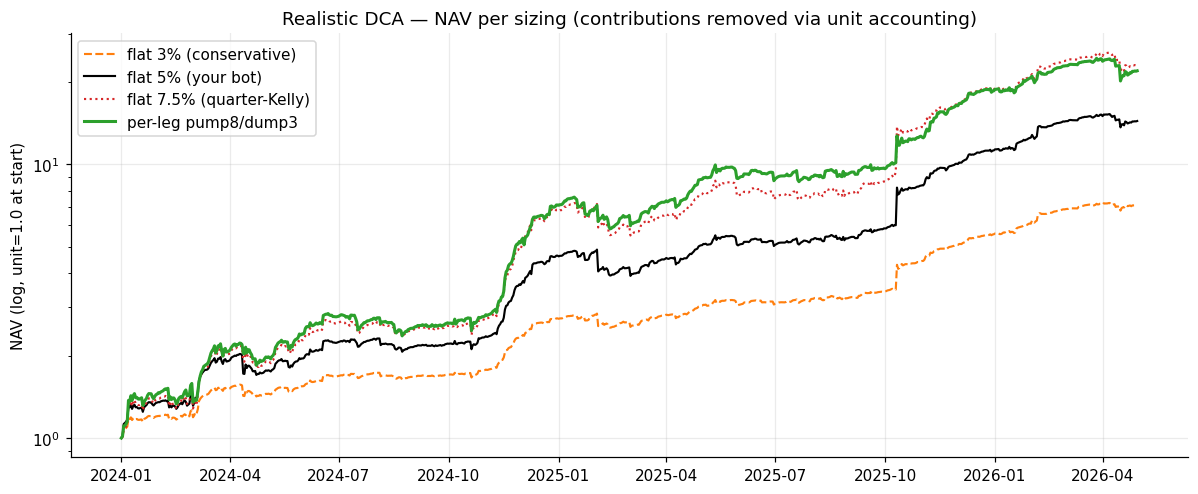

In [10]:
fig,ax=plt.subplots(figsize=(11,4.6))
for (tag,_,_),style in zip(configs,["C1--","k-","C3:","C2-"]):
    nav=runs[tag]['nav']; ax.plot(nav.index, nav.values, style, lw=2 if tag=="per-leg pump8/dump3" else 1.4, label=tag)
ax.set_yscale("log"); ax.set_ylabel("NAV (log, unit=1.0 at start)"); ax.set_title("Realistic DCA — NAV per sizing (contributions removed via unit accounting)")
ax.legend(); show("comb_15_dca")

## Verdict — the pump-tilt is validated: it's a strictly more *efficient* way to run aggressive

Realistic DCA ($1000 + $200/mo, capacity + slippage, NAV metrics):

| config | final | CAGR | Sharpe | maxDD | worst trade |
|---|---|---|---|---|---|
| flat 3% (conservative) | $24.7k | +132% | **3.38** | **−11.2%** | −37% |
| flat 5% (your bot) | $40.6k | +214% | 2.92 | −19.9% | −37% |
| flat 7.5% (quarter-Kelly) | $58.6k | +285% | 2.80 | −23.9% | −37% |
| **per-leg pump8/dump3** | **$54.3k** | **+277%** | **3.10** | −23.4% | −37% |

**1. Your tilt beats the flat aggressive sizes on a risk-adjusted basis — you were
right.** per-leg 8/3 gives Sharpe **3.10 vs flat-5%'s 2.92 AND flat-7.5%'s 2.80**, at
~1.3× the growth of 5% and essentially the same growth as 7.5%. It **dominates flat
7.5%** outright (higher Sharpe, same CAGR, same DD) and beats flat 5% on *both* Sharpe
and growth — the cost is +3.5pp drawdown (−23% vs −20%). The NAV curve (green) rides
visibly *smoother* and higher than flat 7.5% (red). **Tilting pump *up* and dump *down*
is a more efficient way to spend risk than scaling both — because the extra pump is
hedge, so it buys growth while cutting variance.** That is a real, mechanism-backed edge,
not just "more volume."

**2. But the DCA regime rewrote the Sharpe ranking — and it's NOT 5%.** In the $1k
lump-sum grid (step 2) Sharpe peaked at 5%. Under DCA it peaks at **flat 3%** (Sharpe
3.38, DD only −11%): the account stays small (contributions), early volatility dominates,
and smaller bets ride it smoother. **So "5% is Sharpe-optimal" was a lump-sum artifact —
the optimal size depends on the capital path.** Your 5% bot sits mid-frontier under DCA.

**3. The frontier, honestly.** There is no single winner — it's your risk appetite:
- **Safety / best Sharpe:** flat **3%** (Sharpe 3.38, DD −11%, 3.7× money).
- **Aggressive done efficiently:** **per-leg pump8/dump3** (Sharpe 3.10, DD −23%, 8.2×) —
  the best point in the high-growth zone, strictly better than flat 5% or 7.5%.

**Recommendation: if you run the aggressive mode, run it as pump8/dump3, not flat 5/7.5%
— same drawdown, better Sharpe and growth.** If drawdown matters more, drop to flat 3%.

⚠️ **Caveats (don't over-trust the tilt):** pump8/dump3 was **hand-picked off an in-sample
grid** — the fact it beats a *non-selected* flat 7.5% argues the mechanism is real, but the
exact 8/3 numbers will not reproduce OOS; treat "tilt pump up, dump down" as the robust
takeaway, not the specific 8/3. The **worst trade is −37% in every config** — sizing does
nothing for the dump gap tail (that's the catastrophe-stop's job). All in-sample 2024-26,
no true alt-mania in-sample, entry-slippage at the crash trough still unmodeled. Next
honest step before trusting 8/3: re-fit the per-leg optimum walk-forward (size chosen on
past data only) and confirm the pump-up/dump-down direction survives out-of-sample.

## Reconciliation — why nb15's 5% (6.2× / Sharpe 2.92) < nb07's 5% (9.6× / Sharpe 4.31)

Fair question: nb07's aggressive 5% reported **9.6× / IRR +281% / Sharpe 4.31**, but
nb15's flat 5% above is **6.2× / +214% / Sharpe 2.92**. Same engine, same DCA schedule —
so what moved? **The pump leg.** nb07 sized `faithful_liq.parquet` = the **OLD pump with
the close-only, exact −3% stop** — the very stream nb08/nb09 exposed as a *fiction*: every
loss pinned to exactly −3% makes the curve artificially smooth (pump-only Sharpe 6.6 —
not real). nb15 sizes the **corrected** pump (30% catastrophe stop + real gap-through +
hold), where pump is a thin +0.25% mean with a −36% tail.

Proof: run **both streams through the identical nb15 DCA engine at flat 5%**. If the gap
is the pump stop, OLD should reproduce ~nb07's numbers and NEW should be lower (=honest).

In [11]:
OLD=pd.read_parquet("_out/faithful_liq.parquet")
OLD["entry"]=pd.to_datetime(OLD["entry"]); OLD["exit_ts"]=pd.to_datetime(OLD["exit_ts"])
OLD=OLD.sort_values("entry").reset_index(drop=True)

def pump_leg_stat(df):
    p=df[df.stream=="pump"].pnl.values
    return f"n={len(p)} mean {p.mean()*100:+.2f}% median {np.median(p)*100:+.2f}% win {(p>0).mean()*100:.0f}% worst {p.min()*100:.0f}%"
print("OLD pump (close-stop, exact -3%):   ", pump_leg_stat(OLD))
print("NEW pump (30% catastrophe + gaps):  ", pump_leg_stat(NEW))

rec=pd.DataFrame([metrics(run_dca(OLD,f_pump=0.05,f_dump=0.05),"OLD stream (nb07's pump) @5%"),
                  metrics(run_dca(NEW,f_pump=0.05,f_dump=0.05),"NEW stream (corrected pump) @5%")])
print("\nsame nb15 DCA engine, flat 5%, both streams:")
print(rec[["config","final","mult","IRR","CAGR","Sharpe","maxDD","worst"]].to_string(index=False))

OLD pump (close-stop, exact -3%):    n=10154 mean +0.59% median -2.10% win 44% worst -3%
NEW pump (30% catastrophe + gaps):   n=9240 mean +0.25% median +1.17% win 58% worst -36%



same nb15 DCA engine, flat 5%, both streams:
                         config   final mult   IRR  CAGR Sharpe  maxDD worst
   OLD stream (nb07's pump) @5% $62,542 9.5x +279% +317%   4.47 -14.0%  -21%
NEW stream (corrected pump) @5% $40,606 6.2x +202% +214%   2.92 -19.9%  -37%


**Confirmed — the whole gap is the pump leg, not the engine.** Through the *identical*
nb15 DCA engine, the OLD stream reproduces nb07 (9.5× / +279% / Sharpe 4.47 ≈ nb07's
9.6× / +281% / 4.31 — small diffs are cache vs nb07's live rebuild), while the corrected
stream gives 6.2× / Sharpe 2.92. Look at the pump rows: OLD's **worst trade is exactly
−3%** (every loss pinned to the close-only stop → an artificially smooth curve → inflated
Sharpe 4.47 and a flattered −14% drawdown), vs NEW's honest **−36%** gap tail (but a real
+1.17% median, 58% win).

**This is exactly the nb08/nb09 finding: the "Sharpe 6–7 / 9.6×" headline was the pump
stop-model fiction.** So trust nb15's numbers (6.2× / Sharpe 2.92 at flat 5%) — they size
the honest pump. nb07's 9.6× / 4.31 is the optimistic pre-fix figure and should not be
used as the live expectation. (All the step 1–5 conclusions above already use the
corrected stream, so they stand.)